<a href="https://colab.research.google.com/github/IGardocki/First-Initial-vs-Medical-Conditions/blob/main/First_vs_medical_conditions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [69]:
# This explores whether there is any statistical significance between a person's first inital and medical conditions they may experience.

# This uses a synthetic dataset representative of Massachusetts cities (Boston, Worcester, Springfield). The dataset can be found here:
# https://github.com/synthetichealth/synthea-sample-data/blob/main/downloads/10k_synthea_covid19_csv.zip

In [70]:
import pandas as pd

In [71]:
# load data
conditions = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/conditions.csv')
patients = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/patients.csv')
display(patients.head())
display(conditions.head())

,Id,BIRTHDATE,DEATHDATE,SSN,DRIVERS,PASSPORT,PREFIX,FIRST,LAST,SUFFIX,...,BIRTHPLACE,ADDRESS,CITY,STATE,COUNTY,ZIP,LAT,LON,HEALTHCARE_EXPENSES,HEALTHCARE_COVERAGE
0,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,2017-08-24,NaN,999-68-6630,NaN,NaN,NaN,Jacinto644,Kris249,NaN,...,Beverly Massachusetts US,888 Hickle Ferry Suite 38,Springfield,Massachusetts,Hampden County,1106.0,42.151961,-72.598959,8446.49,1499.08
1,067318a4-db8f-447f-8b6e-f2f61e9baaa5,2016-08-01,NaN,999-15-5895,NaN,NaN,NaN,Alva958,Krajcik437,NaN,...,Boston Massachusetts US,1048 Skiles Trailer,Walpole,Massachusetts,Norfolk County,2081.0,42.177370,-71.281353,89893.40,1845.72
2,ae9efba3-ddc4-43f9-a781-f72019388548,1992-06-30,NaN,999-27-3385,S99971451,X53218815X,Mr.,Jayson808,Fadel536,NaN,...,Springfield Massachusetts US,1056 Harris Lane Suite 70,Chicopee,Massachusetts,Hampden County,1020.0,42.181642,-72.608842,577445.86,3528.84
3,199c586f-af16-4091-9998-ee4cfc02ee7a,2004-01-09,NaN,999-73-2461,S99956432,NaN,NaN,Jimmie93,Harris789,NaN,...,Worcester Massachusetts US,201 Mitchell Lodge Unit 67,Pembroke,Massachusetts,Plymouth County,NaN,42.075292,-70.757035,336701.72,2705.64
4,353016ea-a0ff-4154-85bb-1cf8b6cedf20,1996-11-15,NaN,999-60-7372,S99917327,X58903159X,Mr.,Gregorio366,Auer97,NaN,...,Patras Achaea GR,1050 Lindgren Extension Apt 38,Boston,Massachusetts,Suffolk County,2135.0,42.352434,-71.028610,484076.34,3043.04


,START,STOP,PATIENT,ENCOUNTER,CODE,DESCRIPTION
0,2019-02-15,2019-08-01,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,d5ee30a9-362f-429e-a87a-ee38d999b0a5,65363002,Otitis media
1,2019-10-30,2020-01-30,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,8bca6d8a-ab80-4cbf-8abb-46654235f227,65363002,Otitis media
2,2020-03-01,2020-03-30,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,681c380b-3c84-4c55-80a6-db3d9ea12fee,386661006,Fever (finding)
3,2020-03-01,2020-03-01,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,681c380b-3c84-4c55-80a6-db3d9ea12fee,840544004,Suspected COVID-19
4,2020-03-01,2020-03-30,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,681c380b-3c84-4c55-80a6-db3d9ea12fee,840539006,COVID-19


In [72]:
# extract first initial
patients['initial'] = patients['FIRST'].str[0].str.upper()
patients.head()

,Id,BIRTHDATE,DEATHDATE,SSN,DRIVERS,PASSPORT,PREFIX,FIRST,LAST,SUFFIX,...,ADDRESS,CITY,STATE,COUNTY,ZIP,LAT,LON,HEALTHCARE_EXPENSES,HEALTHCARE_COVERAGE,initial
0,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,2017-08-24,NaN,999-68-6630,NaN,NaN,NaN,Jacinto644,Kris249,NaN,...,888 Hickle Ferry Suite 38,Springfield,Massachusetts,Hampden County,1106.0,42.151961,-72.598959,8446.49,1499.08,J
1,067318a4-db8f-447f-8b6e-f2f61e9baaa5,2016-08-01,NaN,999-15-5895,NaN,NaN,NaN,Alva958,Krajcik437,NaN,...,1048 Skiles Trailer,Walpole,Massachusetts,Norfolk County,2081.0,42.177370,-71.281353,89893.40,1845.72,A
2,ae9efba3-ddc4-43f9-a781-f72019388548,1992-06-30,NaN,999-27-3385,S99971451,X53218815X,Mr.,Jayson808,Fadel536,NaN,...,1056 Harris Lane Suite 70,Chicopee,Massachusetts,Hampden County,1020.0,42.181642,-72.608842,577445.86,3528.84,J
3,199c586f-af16-4091-9998-ee4cfc02ee7a,2004-01-09,NaN,999-73-2461,S99956432,NaN,NaN,Jimmie93,Harris789,NaN,...,201 Mitchell Lodge Unit 67,Pembroke,Massachusetts,Plymouth County,NaN,42.075292,-70.757035,336701.72,2705.64,J
4,353016ea-a0ff-4154-85bb-1cf8b6cedf20,1996-11-15,NaN,999-60-7372,S99917327,X58903159X,Mr.,Gregorio366,Auer97,NaN,...,1050 Lindgren Extension Apt 38,Boston,Massachusetts,Suffolk County,2135.0,42.352434,-71.028610,484076.34,3043.04,G


In [73]:
patients.shape

(12352, 26)

In [74]:
# merge datasets linking the condition to the patient using the ID
df = pd.merge(conditions, patients[['Id', 'initial']],
              left_on='PATIENT', right_on='Id')
df.head()


,START,STOP,PATIENT,ENCOUNTER,CODE,DESCRIPTION,Id,initial
0,2019-02-15,2019-08-01,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,d5ee30a9-362f-429e-a87a-ee38d999b0a5,65363002,Otitis media,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,J
1,2019-10-30,2020-01-30,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,8bca6d8a-ab80-4cbf-8abb-46654235f227,65363002,Otitis media,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,J
2,2020-03-01,2020-03-30,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,681c380b-3c84-4c55-80a6-db3d9ea12fee,386661006,Fever (finding),f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,J
3,2020-03-01,2020-03-01,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,681c380b-3c84-4c55-80a6-db3d9ea12fee,840544004,Suspected COVID-19,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,J
4,2020-03-01,2020-03-30,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,681c380b-3c84-4c55-80a6-db3d9ea12fee,840539006,COVID-19,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,J


In [75]:
# Correlation Matrix (Initial vs Condition)
# This counts how many times each initial appears with each disease
matrix = pd.crosstab(df['initial'], df['DESCRIPTION'])
matrix

DESCRIPTION,Acquired coagulation disorder (disorder),Acute Cholecystitis,Acute allergic reaction,Acute bacterial sinusitis (disorder),Acute bronchitis (disorder),Acute deep venous thrombosis (disorder),Acute pulmonary embolism (disorder),Acute respiratory distress syndrome (disorder),Acute respiratory failure (disorder),Acute viral pharyngitis (disorder),...,Suspected COVID-19,Suspected lung cancer (situation),Tear of meniscus of knee,Third degree burn,Traumatic brain injury (disorder),Tubal pregnancy,Viral sinusitis (disorder),Vomiting symptom (finding),Wheezing (finding),Whiplash injury to neck
initial,,,,,,,,,,,,,,,,,,,,,
A,5,0,1,4,45,48,33,10,57,46,...,655,15,1,0,0,27,111,20,150,5
B,8,0,1,4,27,36,28,14,50,36,...,402,5,0,0,0,15,59,24,91,6
C,18,1,0,16,73,51,52,28,79,52,...,730,17,1,0,1,19,127,38,138,4
D,5,0,2,6,42,39,33,15,55,50,...,574,11,0,1,1,24,125,35,120,6
E,10,1,0,2,29,38,33,19,60,63,...,518,10,0,0,0,27,89,27,106,5
F,5,0,0,2,13,16,13,6,17,11,...,220,2,0,0,1,5,41,14,40,2
G,5,0,0,7,24,18,26,9,30,25,...,338,6,0,0,0,14,44,24,54,1
H,1,0,1,2,27,18,22,5,22,25,...,289,6,1,0,0,7,41,20,57,0
I,2,0,0,0,12,10,11,3,15,16,...,136,1,0,0,0,1,33,10,23,1


In [76]:
# Calculate percentage of each initial that has a specific condition
# Divide each row by its total, giving you a 'Rate' per initial
matrix_pct = matrix.div(matrix.sum(axis=1), axis=0) * 100

# top 10 most common conditions for initial 'A' by percentage
print(matrix_pct.loc['A'].sort_values(ascending=False).head(10))

DESCRIPTION
Suspected COVID-19                         7.784645
COVID-19                                   7.546946
Fever (finding)                            6.905158
Cough (finding)                            5.431424
Body mass index 30+ - obesity (finding)    4.361778
Loss of taste (finding)                    4.005229
Prediabetes                                3.458522
Anemia (disorder)                          3.220822
Hypertension                               2.769194
Fatigue (finding)                          2.686000
Name: A, dtype: float64


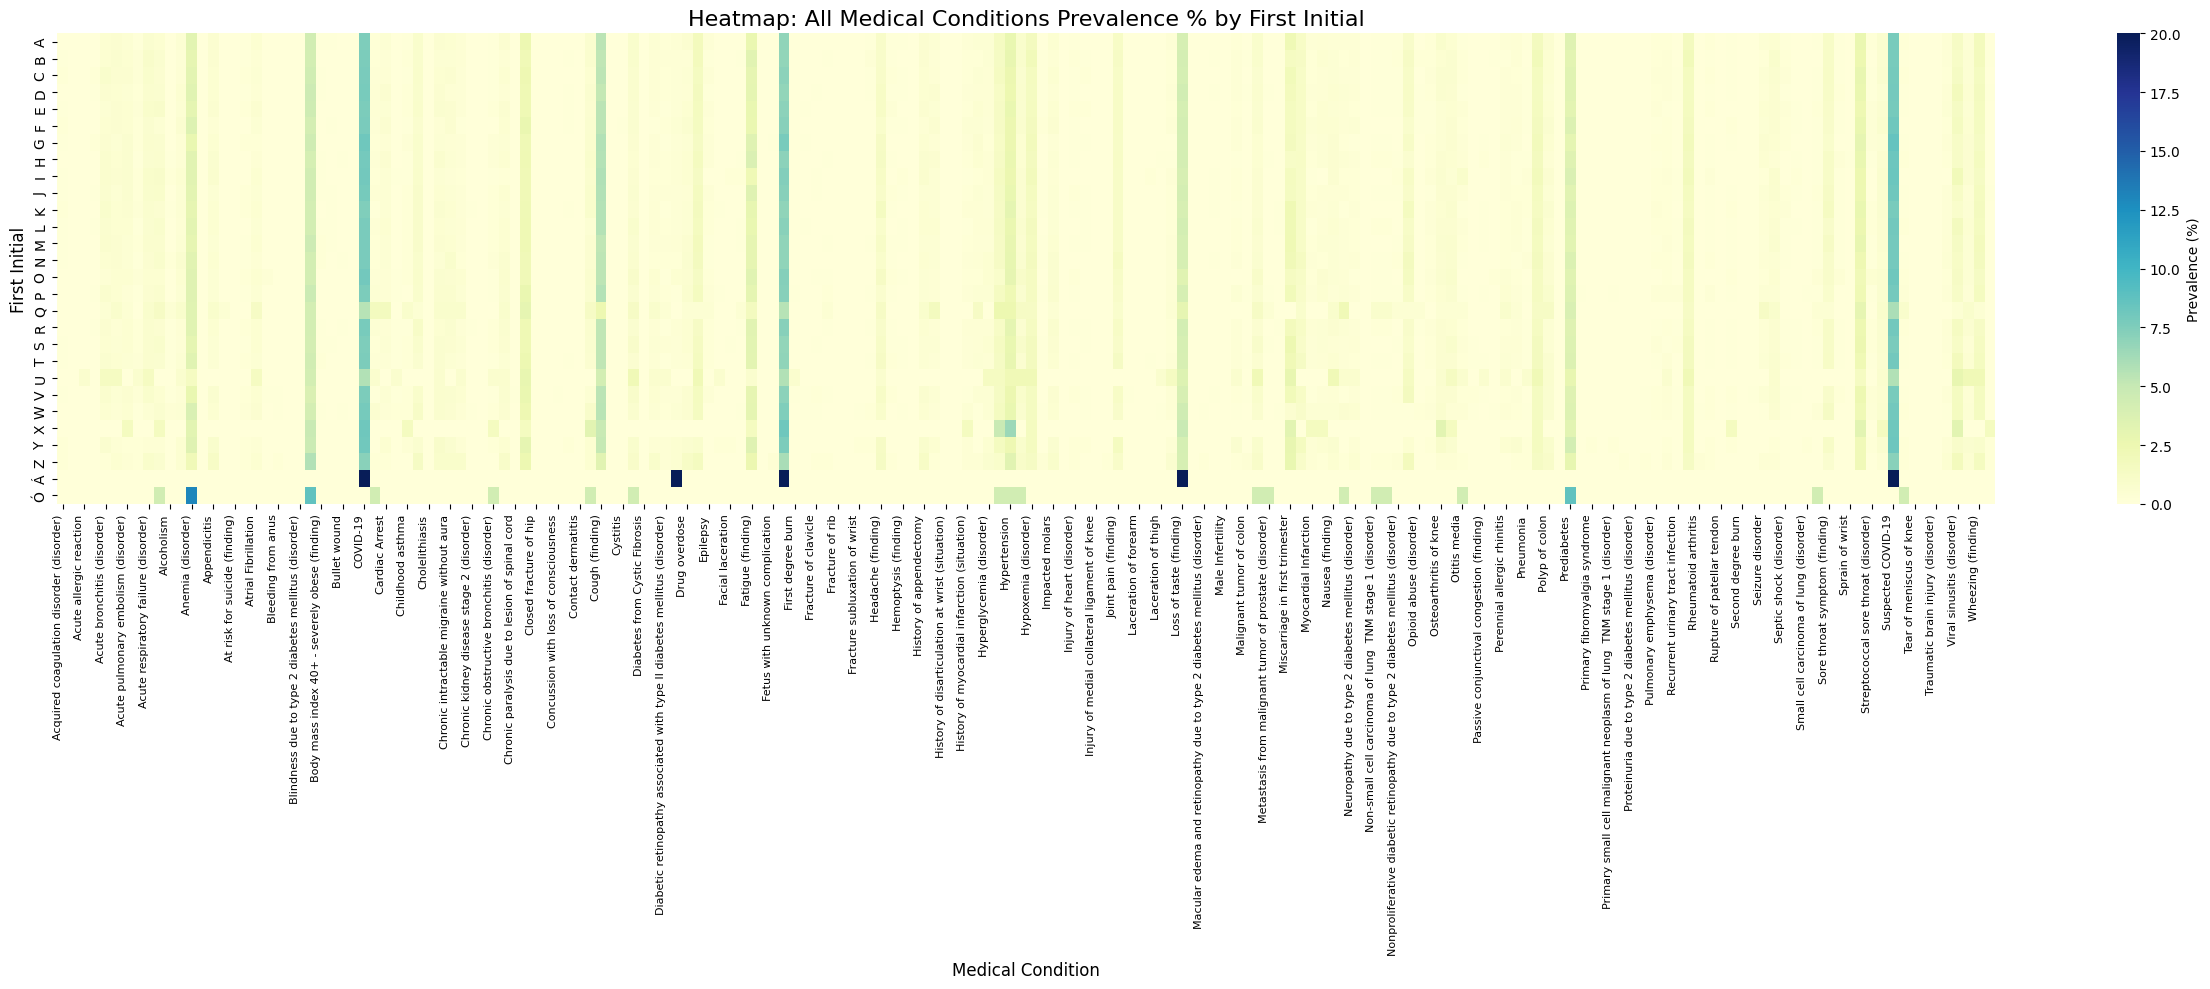

In [77]:
import seaborn as sns
import matplotlib.pyplot as plt

# use data normalized by initial
subset_matrix = matrix_pct

plt.figure(figsize=(25, 10))
sns.heatmap(subset_matrix, annot=False, cmap="YlGnBu", cbar_kws={'label': 'Prevalence (%)'})

plt.title("Heatmap: All Medical Conditions Prevalence % by First Initial", fontsize=16)
plt.xlabel("Medical Condition", fontsize=12)
plt.ylabel("First Initial", fontsize=12)
plt.xticks(rotation=90, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

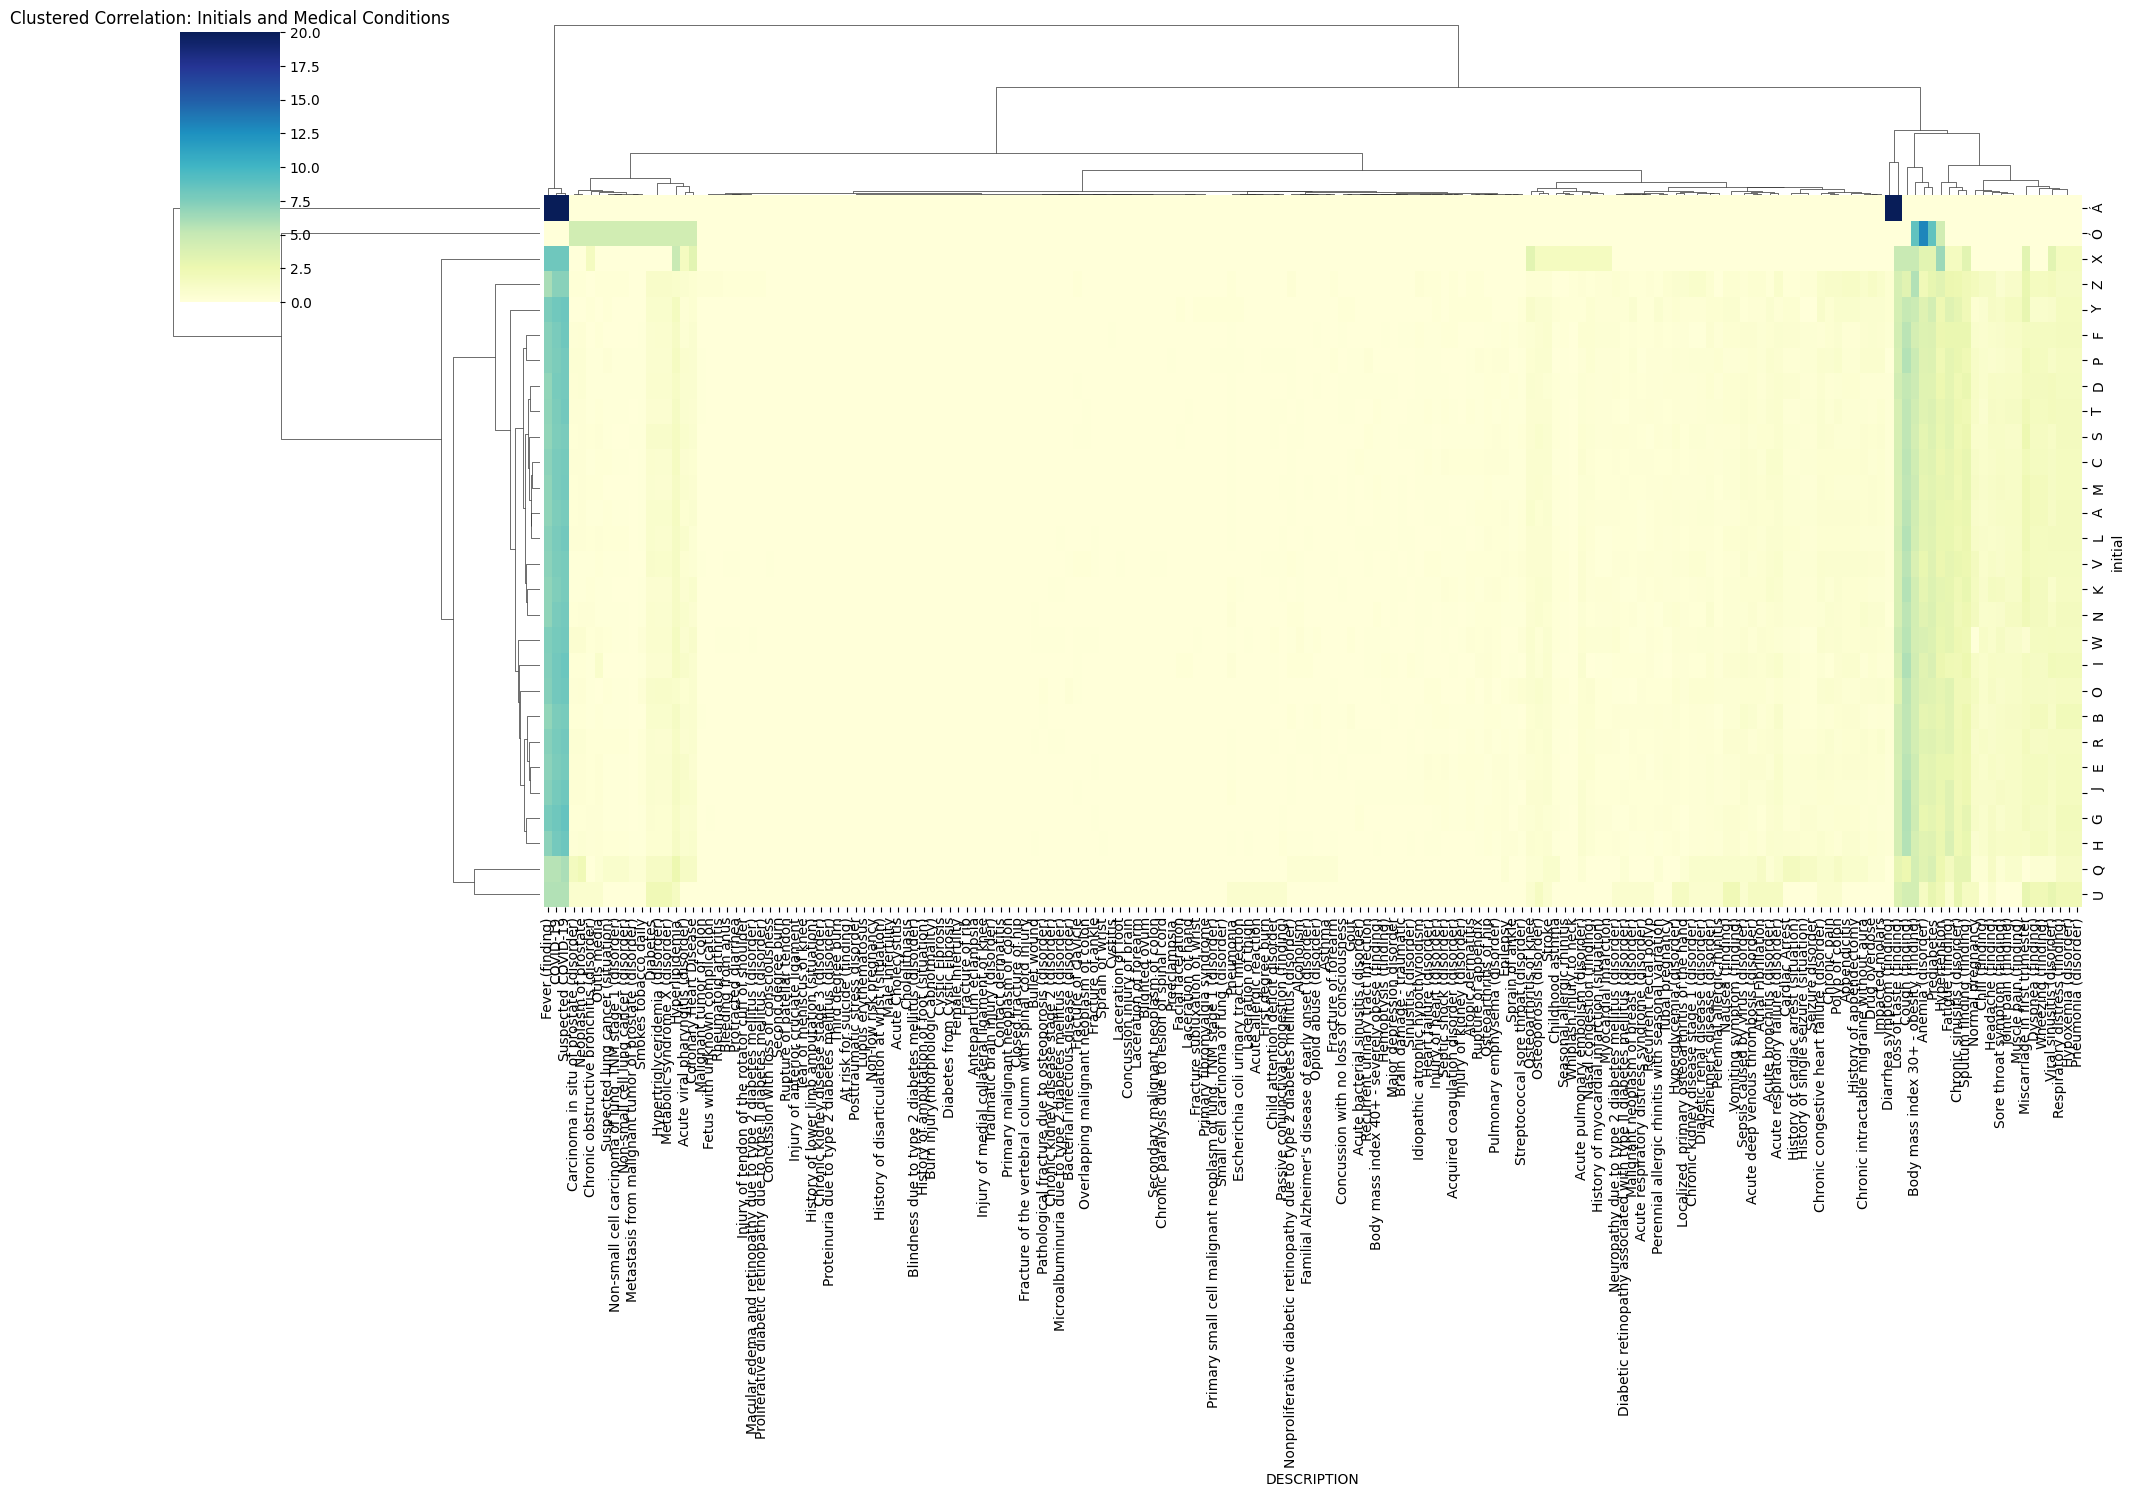

In [78]:
# group similar initials and similar diseases together
sns.clustermap(matrix_pct,
               figsize=(20, 15),
               cmap="YlGnBu",
               method='ward',
               xticklabels=True,
               yticklabels=True)

plt.title("Clustered Correlation: Initials and Medical Conditions")
plt.show()

In [79]:
# initial and the number of patients for each
initial_counts = patients['initial'].value_counts().sort_index()

print("Distribution of Initials:")
print(initial_counts)

Distribution of Initials:
initial
A     909
B     520
C     969
D     773
E     722
F     293
G     454
H     391
I     188
J     943
K     482
L     963
M    1142
N     320
O     161
P     232
Q      27
R     736
S     807
T     624
U      12
V     271
W     264
X      10
Y      74
Z      60
Á       1
Ó       4
Name: count, dtype: int64


In [80]:
import pandas as pd
from scipy.stats import chi2_contingency

significant_results = []
total_n = matrix.sum().sum()

for initial in matrix.index:
    for condition in matrix.columns:
        # Build a 2x2 table for this specific Initial vs Condition
        # [ [In-Group Has Condition, In-Group No Condition],
        #   [Out-Group Has Condition, Out-Group No Condition] ]

        in_group_has = matrix.loc[initial, condition]
        in_group_no = matrix.loc[initial].sum() - in_group_has

        out_group_has = matrix[condition].sum() - in_group_has
        out_group_total = total_n - matrix.loc[initial].sum()
        out_group_no = out_group_total - out_group_has

        contingency = [[in_group_has, in_group_no],
                       [out_group_has, out_group_no]]

        if in_group_has > 0:
            chi2, p, dof, ex = chi2_contingency(contingency)

            if p < 0.05:
                significant_results.append({
                    'Initial': initial,
                    'Condition': condition,
                    'p-value': round(p, 4),
                    'Count': in_group_has
                })

sig_df = pd.DataFrame(significant_results).sort_values('p-value')

print(f"Found {len(sig_df)} statistically significant correlations!")
display(sig_df.head(20))

Found 138 statistically significant correlations!


,Initial,Condition,p-value,Count
43,I,Otitis media,0.0000,15
119,W,Normal pregnancy,0.0000,3
116,W,Miscarriage in first trimester,0.0000,14
81,Q,Neoplasm of prostate,0.0000,5
133,Ó,Metastasis from malignant tumor of prostate (d...,0.0000,1
73,O,Bacterial infectious disease (disorder),0.0001,4
130,Á,Diarrhea symptom (finding),0.0001,1
114,W,Alcoholism,0.0001,8
7,B,Gout,0.0002,13
95,S,Miscarriage in first trimester,0.0003,191


In [81]:
# If you use the standard significance threshold of alpha = 0.05 (5%), then by definition, 5% of your tests will be falsely significant
# if there is actually no real relationship between the variables. The Bonferroni correction solves the "False Positive" problem by raising
# the bar for what counts as significant. Bonferroni takes your total "allowable error" and splits it equally across every single test you run.
# Instead of letting each test have its own 5% chance of being a fluke, the entire group of tests has to share that 5% chance.


# calculate total number of tests performed
num_tests = len(matrix.index) * len(matrix.columns)
original_alpha = 0.05
bonferroni_alpha = original_alpha / num_tests

print(f"Number of tests: {num_tests}")
print(f"Original Alpha: {original_alpha}")
print(f"New Bonferroni-Adjusted Alpha: {bonferroni_alpha:.6f}")

truly_significant = sig_df[sig_df['p-value'] < bonferroni_alpha]

print(f"Found {len(truly_significant)} correlations that survived Bonferroni!")
display(truly_significant)

Number of tests: 5040
Original Alpha: 0.05
New Bonferroni-Adjusted Alpha: 0.000010
Found 5 correlations that survived Bonferroni!


,Initial,Condition,p-value,Count
43,I,Otitis media,0.0,15
119,W,Normal pregnancy,0.0,3
116,W,Miscarriage in first trimester,0.0,14
81,Q,Neoplasm of prostate,0.0,5
133,Ó,Metastasis from malignant tumor of prostate (d...,0.0,1


In [82]:
# show relative risk of significant findings compared to the average person
import numpy as np

risk_analysis = truly_significant.copy()

def get_relative_risk(row):
    initial = row['Initial']
    condition = row['Condition']

    # probability in the 'Initial' group
    group_total = matrix.loc[initial].sum()
    group_cases = matrix.loc[initial, condition]
    prob_group = group_cases / group_total

    # probability in everyone else
    others_total = total_n - group_total
    others_cases = matrix[condition].sum() - group_cases
    prob_others = others_cases / others_total

    # relative risk
    if prob_others == 0:
        return np.nan
    return prob_group / prob_others

risk_analysis['Relative_Risk'] = risk_analysis.apply(get_relative_risk, axis=1)
risk_analysis['Interpretation'] = risk_analysis['Relative_Risk'].apply(
    lambda x: f"{round(x, 2)}x more likely" if x > 1 else f"{round(1/x, 2)}x less likely"
)

risk_analysis = risk_analysis.sort_values(by='Relative_Risk', ascending=False)
print(f"Analysis of {len(risk_analysis)} Truly Significant Correlations:")
display(risk_analysis[['Initial', 'Condition', 'Relative_Risk', 'Interpretation', 'p-value']])

Analysis of 5 Truly Significant Correlations:


,Initial,Condition,Relative_Risk,Interpretation,p-value
133,Ó,Metastasis from malignant tumor of prostate (d...,81.625802,81.63x more likely,0.0
81,Q,Neoplasm of prostate,7.151679,7.15x more likely,0.0
43,I,Otitis media,4.125530,4.13x more likely,0.0
116,W,Miscarriage in first trimester,0.290087,3.45x less likely,0.0
119,W,Normal pregnancy,0.106576,9.38x less likely,0.0


In [83]:
# Prostate cancer or neoplasm of prostate indicates the patient is male. Pregnancy indicates that someone is female.

# find percentage of people who are male or female for initials where there is statistical significance related to gender.
gender_dist = pd.crosstab(patients['initial'], patients['GENDER'])

target_initials = ['Ó', 'Q', 'W']
existing_targets = [i for i in target_initials if i in gender_dist.index]
subset = gender_dist.loc[existing_targets].copy()

subset['Total'] = subset['M'] + subset['F']
subset['% Male'] = (subset['M'] / subset['Total'] * 100).round(2)
subset['% Female'] = (subset['F'] / subset['Total'] * 100).round(2)

print("Gender Distribution for Initials Ó, Q and W:")
display(subset)

Gender Distribution for Initials Ó, Q and W:


GENDER,F,M,Total,% Male,% Female
initial,,,,,
Ó,0,4,4,100.00,0.00
Q,3,24,27,88.89,11.11
W,61,203,264,76.89,23.11


In [84]:
# i was curious about what patients have first inital Ó
o_patients = patients[patients['initial'] == 'Ó']
display(o_patients)

,Id,BIRTHDATE,DEATHDATE,SSN,DRIVERS,PASSPORT,PREFIX,FIRST,LAST,SUFFIX,...,ADDRESS,CITY,STATE,COUNTY,ZIP,LAT,LON,HEALTHCARE_EXPENSES,HEALTHCARE_COVERAGE,initial
2083,438b4e6d-0cfe-44c8-98ba-172dec5b511e,1957-07-05,2016-11-29,999-19-1088,S99929645,X25096421X,Mr.,Óscar156,Valenzuela371,NaN,...,381 Schumm Center,Boston,Massachusetts,Suffolk County,2130.0,42.286810,-71.091796,1509719.84,5825.24,Ó
2685,aab28278-4d1f-4e0c-a3c7-765ce55b6bde,2019-12-09,NaN,999-93-1361,NaN,NaN,NaN,Óscar156,Cabrera242,NaN,...,710 Schultz Divide Suite 90,Newburyport,Massachusetts,Essex County,NaN,42.815702,-70.859183,15560.53,516.64,Ó
4715,81d3b2d7-589f-46fc-9f63-75603efa825a,1944-09-07,1995-03-23,999-16-4819,S99994274,X13248188X,Mr.,Óscar156,Castillo397,NaN,...,996 Reynolds Haven,Holyoke,Massachusetts,Hampden County,NaN,42.235444,-72.645768,157290.65,6241.16,Ó
10342,97d51719-f3fc-4ed9-9b5f-7ef58883b57e,1937-12-27,2004-08-17,999-36-4940,S99948913,X15904667X,Mr.,Óscar156,Villareal516,NaN,...,657 Spencer Corner,Beverly,Massachusetts,Essex County,NaN,42.569283,-70.846669,1510334.70,7992.02,Ó


In [85]:
# also q patients
q_patients = patients[patients['initial'] == 'Q']
display(q_patients.head())

,Id,BIRTHDATE,DEATHDATE,SSN,DRIVERS,PASSPORT,PREFIX,FIRST,LAST,SUFFIX,...,ADDRESS,CITY,STATE,COUNTY,ZIP,LAT,LON,HEALTHCARE_EXPENSES,HEALTHCARE_COVERAGE,initial
480,7f601884-8f36-4be6-9a50-fe17fa05527c,2009-02-20,NaN,999-56-3326,NaN,NaN,NaN,Quintin944,Jenkins714,NaN,...,723 Bode Annex Apt 78,South Hadley,Massachusetts,Hampshire County,NaN,42.213764,-72.623599,292814.98,3758.92,Q
721,da1e7f78-9249-4be6-b837-ac125bd6664e,2015-02-25,NaN,999-16-6157,NaN,NaN,NaN,Quinton758,Conn188,NaN,...,128 Stiedemann Gardens Apt 64,Needham,Massachusetts,Norfolk County,2494.0,42.269067,-71.225954,113836.11,2079.04,Q
943,2b48d267-56a4-4f6c-afb8-587457338e16,1914-10-04,1993-10-18,999-27-7149,S99924101,X62289063X,Mr.,Quinn173,Kutch271,NaN,...,912 Volkman Estate,Worcester,Massachusetts,Worcester County,1545.0,42.277835,-71.889863,1588277.39,90866.04,Q
1043,6ee12582-18b7-4e6f-9abe-3f5b1869039b,1974-02-23,NaN,999-43-1597,S99989562,X83396393X,Mr.,Quentin28,Luettgen772,NaN,...,874 Schimmel Dale,Dudley,Massachusetts,Worcester County,NaN,42.019465,-71.961156,1058985.77,3740.45,Q
1760,297a73ea-b0bc-4892-ad4b-812e1ccd33a2,2001-02-26,NaN,999-81-9927,S99990895,NaN,Mr.,Quentin28,Batz141,NaN,...,834 Ziemann Mews,Cambridge,Massachusetts,Middlesex County,2141.0,42.366478,-71.174604,488891.31,3666.40,Q


In [86]:
# Otitis media is overwhelmingly a pediatric condition, so seeing it show up as a "statistically significant" result
# for a specific initial indicates that that first initial is more common in younger people.

# determine when dataset was made
conditions['START'] = pd.to_datetime(conditions['START'])
reference_date = conditions['START'].max()
ref_year = reference_date.year

print(f"The latest event in this dataset is from the year: {ref_year}")

# find age relative to reference year
patients['BIRTHDATE'] = pd.to_datetime(patients['BIRTHDATE'])
patients['age_at_event'] = ref_year - patients['BIRTHDATE'].dt.year

# group above and below 18 (using the corrected age)
patients['age_group'] = patients['age_at_event'].apply(
    lambda x: 'Younger (<18)' if x < 18 else 'Older (>=18)'
)

The latest event in this dataset is from the year: 2020


In [87]:
# find profiles of people with i names
i_group = patients[patients['initial'] == 'I']

i_dist = i_group['age_group'].value_counts(normalize=True) * 100
pop_dist = patients['age_group'].value_counts(normalize=True) * 100

print(f"--- Age Profile for Initial 'I' (Ref Year: {ref_year}) ---")
print(i_dist)
print("\n--- General Population Age Profile ---")
print(pop_dist)

print("\nMost common 'I' names in this group:")
print(i_group['FIRST'].value_counts().head(5))

--- Age Profile for Initial 'I' (Ref Year: 2020) ---
age_group
Older (>=18)     81.914894
Younger (<18)    18.085106
Name: proportion, dtype: float64

--- General Population Age Profile ---
age_group
Older (>=18)     83.71114
Younger (<18)    16.28886
Name: proportion, dtype: float64

Most common 'I' names in this group:
FIRST
Ira784      8
Irvin970    8
Irwin931    7
Issac619    7
Isaac321    6
Name: count, dtype: int64


In [89]:
# find % of people over and under 18 with i names
conditions['START'] = pd.to_datetime(conditions['START'])
ref_year = conditions['START'].max().year

patients['age'] = ref_year - patients['BIRTHDATE'].dt.year

under_18 = patients[patients['age'] < 18]
over_18 = patients[patients['age'] >= 18]

i_under_18 = (under_18['initial'] == 'I').mean() * 100
i_over_18 = (over_18['initial'] == 'I').mean() * 100

print(f"Dataset Reference Year: {ref_year}")
print("-" * 30)
print(f"Percentage of people UNDER 18 with 'I' names: {i_under_18:.2f}%")
print(f"Percentage of people OVER 18 with 'I' names: {i_over_18:.2f}%")

# calculate relative percentage (liklihood)
if i_over_18 > 0:
    multiplier = i_under_18 / i_over_18
    print(f"\nConclusion: 'I' names are {multiplier:.2f}x more common in children than in adults.")

Dataset Reference Year: 2020
------------------------------
Percentage of people UNDER 18 with 'I' names: 1.69%
Percentage of people OVER 18 with 'I' names: 1.49%

Conclusion: 'I' names are 1.13x more common in children than in adults.


In [91]:
# There were 5 statisically significant realationships between first inital and gender:
# Ó: Metastasis from malignant tumor of prostate
# Q: Neoplasm of prostate
# W: Miscarriage in first trimester AND Normal pregnancy
# I: Otitis media

# Metastasis from malignant tumor of prostate, Neoplasm of prostate, Miscarriage in first trimester, and Normal pregnancy are all gender based conditions.

# The initials Ó, Q, W are all statisically significant based on gender, and all of these initials are much more common in males (See above). In addition, in U.S. Census data,
# names like Quincy, Quentin, and Quinton are almost 100% male, and are more common in older males (who would be more likely to have prostate conditions).

# # Otitis media is overwhelmingly a pediatric condition, so seeing it show up as a "statistically significant" result
# for a specific initial indicates that that first initial is more common in younger people. Analysis above proves that this is indeed true for our dataset.
